In [1]:
#1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#2
!ls "/content/drive/MyDrive/New_folder"

 badodd
 badodd_class_review
 badodd_clean_11
 badodd_remapped_11
 data.yaml
 desktop.ini
 final_11class_combined
 final_11class_split
 final_best.pt
 gettyimages-1501064033-640_adpp.mp4
 images
 images1
 images2
 images_clean
 labels
 labels1
 labels2
 labels_clean
 output_counted1.mp4
 output_counted2.mp4
 prepare_dataset.py
 README.roboflow.txt
'Recording 3.mp4'
'Recording 4.mp4'
'Recording 5.mp4'
 runs
 traffic_update.yaml
 train.ipynb
 train.py
 untitled.py
 WhatsApp1.mp4
 WhatsApp2.mp4
 WhatsApp3.mp4
 WhatsApp4.mp4
 WhatsApp5.mp4
 WhatsApp6.mp4
 WhatsApp7.mp4
 WhatsApp8.mp4
 WhatsApp9.mp4
'WhatsApp Video 2026-04-10 at 10.45.58 PM.mp4'
 yolo26n.pt
 yolov8n.pt


In [3]:
!pip install -q ultralytics


from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 71.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/New_folder/WhatsApp1.mp4",
    save=True,
    device="cpu"
    conf=0.25
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/352) /content/drive/MyDrive/New_folder/WhatsApp1.mp4: 960x544 2 Auto_ricksaws, 1 Bike, 2 Buss, 1 Private_car, 5453.8ms
video 1/1 (frame 2/352) /content/drive/MyDrive/New_folder/WhatsApp1.mp4: 960x544 2 Auto_ricksaws, 1 Bike, 2 Buss, 1 Private_car, 4757.0ms
video 1/1 (frame 3/352) /content/drive/MyDrive/New_folder/WhatsApp1.mp4: 960x544 1 Auto_ricksaw, 1 Bike, 2 Buss, 1 Private_car, 4027.4ms
video 1/1 (frame 4/352) /content/drive/MyDriv

In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/New_folder/WhatsApp5.mp4",
    save=True,
    conf=0.15
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/672) /content/drive/MyDrive/New_folder/WhatsApp5.mp4: 960x544 6 Auto_ricksaws, 7 Private_cars, 1 cng, 86.2ms
video 1/1 (frame 2/672) /content/drive/MyDrive/New_folder/WhatsApp5.mp4: 960x544 5 Auto_ricksaws, 7 Private_cars, 1 cng, 59.7ms
video 1/1 (frame 3/672) /content/drive/MyDrive/New_folder/WhatsApp5.mp4: 960x544 6 Auto_ricksaws, 7 Private_cars, 1 cng, 57.0ms
video 1/1 (frame 4/672) /content/drive/MyDrive/New_folder/WhatsApp5.mp4: 9

In [ ]:
from google.colab import files

files.download("/content/runs/detect/predict/WhatsApp5.avi")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#LOADING VIDEO FOR FREAMING

from ultralytics import YOLO
import cv2

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/drive/MyDrive/New_folder/WhatsApp5.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS:", fps)
print("Width:", w)
print("Height:", h)

FPS: 29.60352422907489
Width: 480
Height: 848


In [ ]:
#COUNT VEHICLE NUMBER

from ultralytics import YOLO
import cv2
from collections import defaultdict

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/drive/MyDrive/New_folder/WhatsApp5.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "/content/vehicle_count_whatsapp5.avi",
    cv2.VideoWriter_fourcc(*"XVID"),
    fps,
    (w, h)
)

# counting line
line_y = int(h * 0.65)

last_center_y = {}
counted_ids = set()
class_counts = defaultdict(int)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.25, verbose=False)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        names = results[0].names

        for box, track_id, cls_id in zip(boxes, ids, cls_ids):
            x1, y1, x2, y2 = map(int, box)
            center_y = int((y1 + y2) / 2)
            label = names[int(cls_id)]

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, f"{label} ID:{track_id}", (x1, max(25, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)

            if track_id in last_center_y:
                prev_y = last_center_y[track_id]
                if prev_y < line_y <= center_y and track_id not in counted_ids:
                    counted_ids.add(track_id)
                    class_counts[label] += 1

            last_center_y[track_id] = center_y

    cv2.line(frame, (0, line_y), (w, line_y), (0, 0, 255), 2)

    total_count = sum(class_counts.values())
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 80
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)
        y_text += 28

    out.write(frame)

cap.release()
out.release()

print("Done. Saved: /content/vehicle_count_whatsapp5.avi")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", sum(class_counts.values()))

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 217ms
Prepared 1 package in 51ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Done. Saved: /content/vehicle_count_whatsapp5.avi
Class-wise counts: {'Auto_ricksaw': 2, 'cng': 1}
Total vehicles: 3


In [ ]:
from google.colab import files
files.download("/content/vehicle_count_whatsapp5.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#UPDATE FOR COUNTING

from ultralytics import YOLO
import cv2
from collections import defaultdict

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/drive/MyDrive/New_folder/WhatsApp5.avi"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "/content/vehicle_count_fixed_zone.avi",
    cv2.VideoWriter_fourcc(*"XVID"),
    fps,
    (w, h)
)

# 🔥 TWO LINES (ZONE)
line1_y = int(h * 0.45)
line2_y = int(h * 0.65)

last_center_y = {}
counted_ids = set()
class_counts = defaultdict(int)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.20, verbose=False)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        names = results[0].names

        for box, track_id, cls_id in zip(boxes, ids, cls_ids):
            x1, y1, x2, y2 = map(int, box)
            center_y = int((y1 + y2) / 2)
            label = names[int(cls_id)]

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.circle(frame, ((x1+x2)//2, center_y), 4, (255,0,0), -1)

            # 🔥 ZONE CROSSING LOGIC
            if track_id in last_center_y:
                prev_y = last_center_y[track_id]

                entered_zone = (
                    (prev_y < line1_y and center_y >= line1_y) or
                    (prev_y > line2_y and center_y <= line2_y)
                )

                if entered_zone and track_id not in counted_ids:
                    counted_ids.add(track_id)
                    class_counts[label] += 1

            last_center_y[track_id] = center_y

    # draw lines
    cv2.line(frame, (0, line1_y), (w, line1_y), (255,0,0), 2)
    cv2.line(frame, (0, line2_y), (w, line2_y), (0,0,255), 2)

    total_count = sum(class_counts.values())

    cv2.putText(frame, f"Total Vehicles: {total_count}", (20,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

    y_text = 80
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20,y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
        y_text += 25

    out.write(frame)

cap.release()
out.release()

print("DONE")

DONE


In [ ]:
from google.colab import files
files.download("/content/vehicle_count_whatsapp5.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!ls "/content/drive/MyDrive/New_folder"

 badodd
 badodd_class_review
 badodd_clean_11
 badodd_remapped_11
 data.yaml
 desktop.ini
 final_11class_combined
 final_11class_split
 final_best.pt
 gettyimages-1501064033-640_adpp.mp4
 images
 images1
 images2
 images_clean
 labels
 labels1
 labels2
 labels_clean
 output_counted1.mp4
 output_counted2.mp4
 prepare_dataset.py
 README.roboflow.txt
'Recording 3.mp4'
'Recording 4.mp4'
'Recording 5.mp4'
 runs
 traffic_update.yaml
 train.ipynb
 train.py
 untitled.py
 WhatsApp1.mp4
 WhatsApp2.mp4
 WhatsApp3.mp4
 WhatsApp4.mp4
 WhatsApp5.mp4
 WhatsApp6.mp4
 WhatsApp7.mp4
 WhatsApp8.mp4
 WhatsApp9.mp4
'WhatsApp Video 2026-04-10 at 10.45.58 PM.mp4'
 yolo26n.pt
 yolov8n.pt


In [ ]:
#TRIAL

import cv2

video_path = "/content/drive/MyDrive/New_folder/WhatsApp5.mp4"  # FIX THIS

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Video not opened")
else:
    print("✅ Video opened successfully")

ret, frame = cap.read()

if not ret:
    print("❌ Could not read frame")
else:
    print("✅ Frame read successfully")
    cv2.imwrite("/content/sample_frame.jpg", frame)

cap.release()

✅ Video opened successfully
✅ Frame read successfully


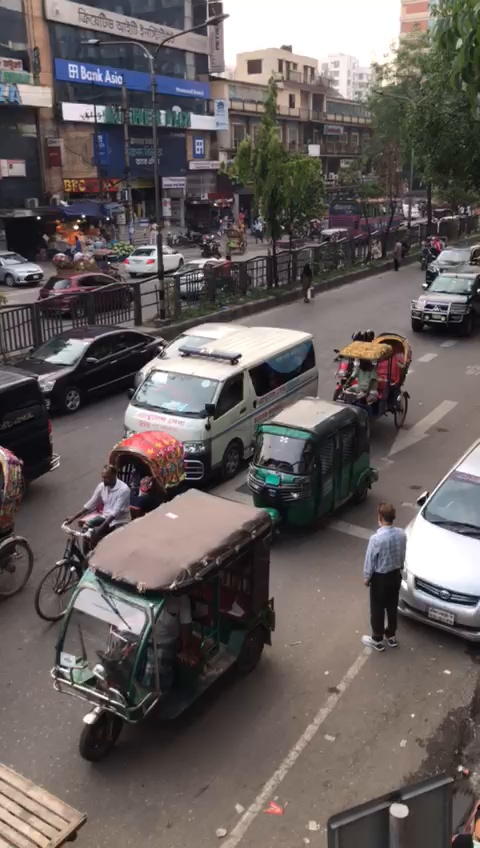

In [ ]:
from IPython.display import Image, display
display(Image("/content/sample_frame.jpg"))

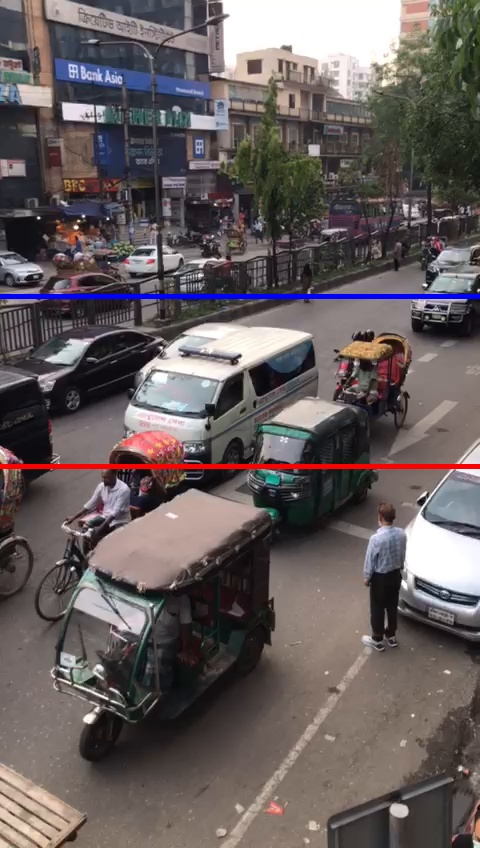

In [ ]:
import cv2
from IPython.display import Image, display

img = cv2.imread("/content/sample_frame.jpg")

h, w = img.shape[:2]

band_top = int(h * 0.35)
band_bottom = int(h * 0.55)

cv2.line(img, (0, band_top), (w, band_top), (255, 0, 0), 3)
cv2.line(img, (0, band_bottom), (w, band_bottom), (0, 0, 255), 3)

cv2.imwrite("/content/sample_frame_with_band.jpg", img)
display(Image("/content/sample_frame_with_band.jpg"))

Saved: /content/sample_frame_whatsapp5.jpg


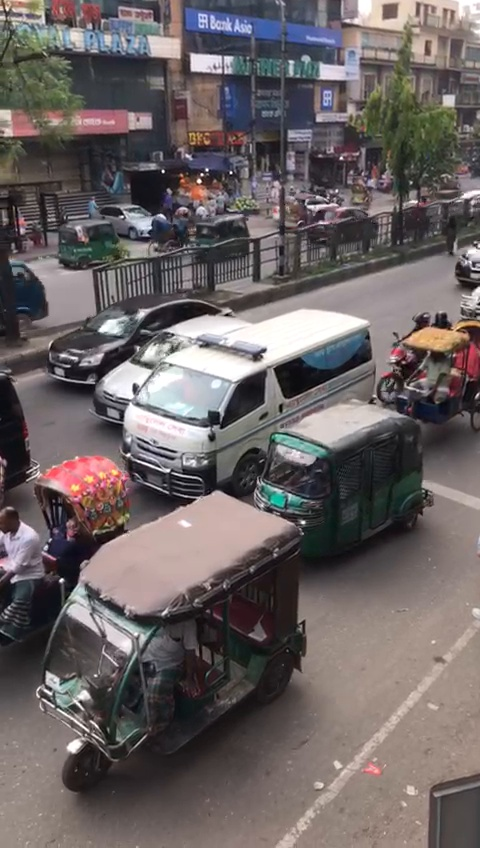

In [ ]:
import cv2
from IPython.display import Image, display

video_path = "/content/drive/MyDrive/New_folder/WhatsApp5.mp4"
cap = cv2.VideoCapture(video_path)

cap.set(cv2.CAP_PROP_POS_FRAMES, 50)  # change frame number if needed
ret, frame = cap.read()
cap.release()

if not ret:
    print("Could not read frame")
else:
    cv2.imwrite("/content/sample_frame_whatsapp5.jpg", frame)
    print("Saved: /content/sample_frame_whatsapp5.jpg")
    display(Image("/content/sample_frame_whatsapp5.jpg"))

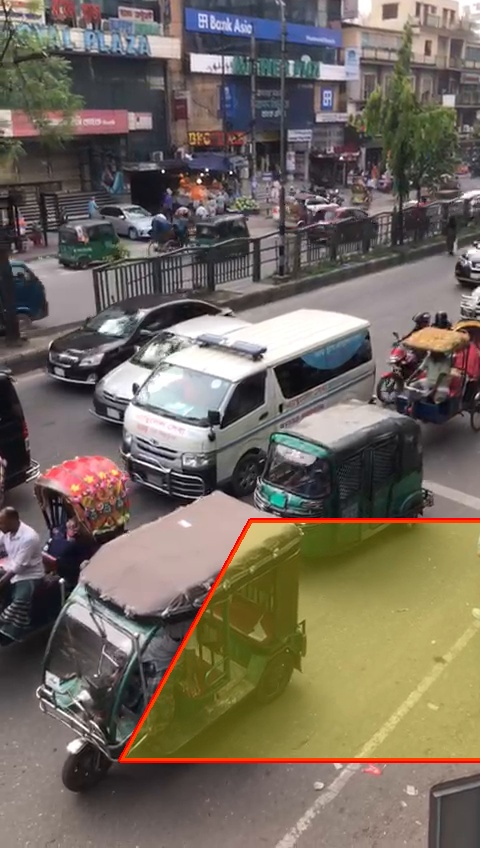

In [ ]:
import cv2
import numpy as np
from IPython.display import Image, display

img = cv2.imread("/content/sample_frame_whatsapp5.jpg")

# Example polygon points for your road area
roi_points = np.array([
    [120, 760],
    [980, 760],
    [860, 520],
    [250, 520]
], dtype=np.int32)

cv2.polylines(img, [roi_points], isClosed=True, color=(0, 0, 255), thickness=4)

overlay = img.copy()
cv2.fillPoly(overlay, [roi_points], color=(0, 255, 255))
img = cv2.addWeighted(overlay, 0.25, img, 0.75, 0)

cv2.imwrite("/content/sample_frame_polygon.jpg", img)
display(Image("/content/sample_frame_polygon.jpg"))

In [ ]:
!pip install -q ultralytics


from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/drive/MyDrive/New_folder/WhatsApp5.mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "/content/vehicle_count_polygon_whatsapp5.avi",
    cv2.VideoWriter_fourcc(*"XVID"),
    fps,
    (w, h)
)

# Adjust these points to your road
roi_points = np.array([
    [120, 760],
    [980, 760],
    [860, 520],
    [250, 520]
], dtype=np.int32)

class_counts = defaultdict(int)
counted_ids = set()

allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.20, verbose=False)

    # draw polygon
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], color=(0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.20, frame, 0.80, 0)
    cv2.polylines(frame, [roi_points], isClosed=True, color=(0, 0, 255), thickness=3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        names = results[0].names

        for box, track_id, cls_id in zip(boxes, ids, cls_ids):
            x1, y1, x2, y2 = map(int, box)
            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)
            label = names[int(cls_id)]

            if label not in allowed_classes:
                continue

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(frame, f"{label} ID:{track_id}", (x1, max(25, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            # Check if center point is inside polygon
            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            if inside >= 0 and track_id not in counted_ids:
                counted_ids.add(track_id)
                class_counts[label] += 1

    total_count = sum(class_counts.values())

    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

    y_text = 80
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 25

    out.write(frame)

cap.release()
out.release()

print("Done. Saved: /content/vehicle_count_polygon_whatsapp5.avi")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", sum(class_counts.values()))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 308ms
Prepared 1 package in 55ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Done. Saved: /content/vehicle_count_polygon_whatsapp5.avi
Class-wise counts: {'Private_car': 1, 'Auto_ricksaw': 4, 'cng': 1, 'Bike': 5}
Total vehicles: 11


In [ ]:
!ls /content

drive			  sample_frame_whatsapp5.jpg
sample_data		  sample_frame_with_band.jpg
sample_frame.jpg	  vehicle_count_polygon_whatsapp5.avi
sample_frame_polygon.jpg


In [ ]:
from google.colab import files
files.download("/content/vehicle_count_polygon_whatsapp5.avi")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!cp "/content/drive/MyDrive/New_folder/WhatsApp5.mp4" /content/

In [ ]:
!ls /content

drive  sample_data  WhatsApp5.mp4


In [ ]:
import cv2

video_path = "/content/WhatsApp5.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Video not opened")
else:
    print("✅ Video opened successfully")

# Try multiple frames (IMPORTANT)
frame_found = False

for i in range(30):   # try first 30 frames
    ret, frame = cap.read()
    if ret:
        frame_found = True
        break

cap.release()

if not frame_found:
    raise ValueError("❌ Could not read any frame")
else:
    print("✅ Frame read successfully")
    cv2.imwrite("/content/sample_frame.jpg", frame)

✅ Video opened successfully
✅ Frame read successfully


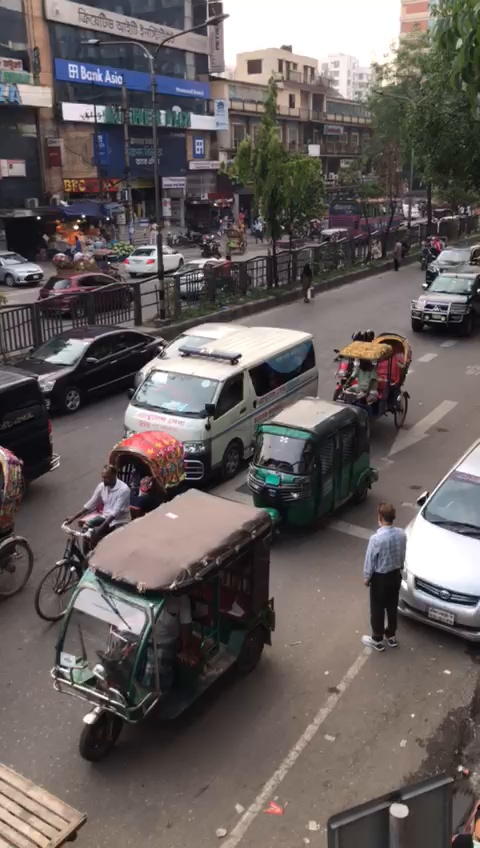

In [ ]:
from IPython.display import Image
Image("/content/sample_frame.jpg")

In [ ]:
import numpy as np

roi_points = np.array([
    [250, 720],   # bottom-left (slightly right)
    [1050, 720],  # bottom-right (extend right)
    [900, 550],   # top-right (lower than before)
    [350, 550]    # top-left (lower)
], dtype=np.int32)

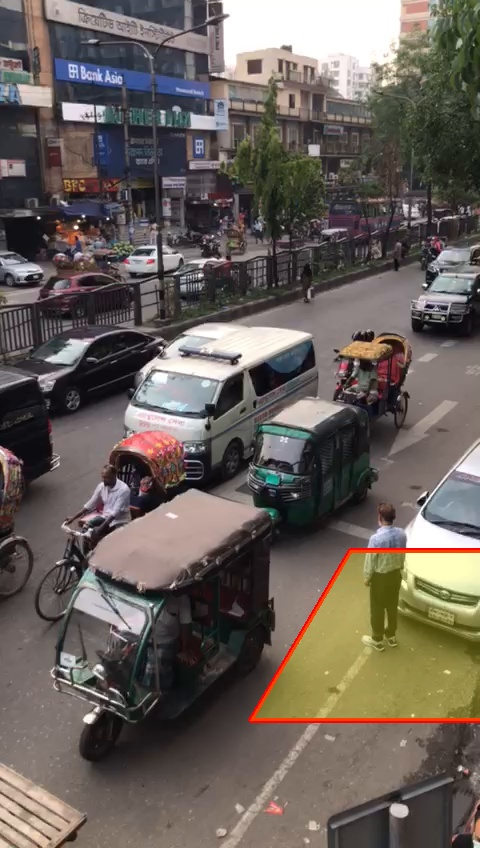

In [ ]:
import cv2
from IPython.display import Image, display

img = cv2.imread("/content/sample_frame.jpg")

cv2.polylines(img, [roi_points], True, (0,0,255), 3)

overlay = img.copy()
cv2.fillPoly(overlay, [roi_points], (0,255,255))
img = cv2.addWeighted(overlay, 0.25, img, 0.75, 0)

cv2.imwrite("/content/check_polygon_final.jpg", img)
display(Image("/content/check_polygon_final.jpg"))

In [ ]:
!pip install -q ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.0 MB/s eta 0:00:00


In [ ]:
import numpy as np

roi_points = np.array([
    [40, 430],    # top-left
    [1140, 430],  # top-right
    [1270, 1180], # bottom-right
    [0, 1180]     # bottom-left
], dtype=np.int32)

print(roi_points)

[[  40  430]
 [1140  430]
 [1270 1180]
 [   0 1180]]


In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/drive/MyDrive/New_folder/WhatsApp5.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    "/content/output_unique_vehicle_count.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

# How many frames a track must stay inside ROI before counting
min_frames_inside = 4

frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.track(frame, persist=True, conf=0.15, verbose=False)

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        names = results[0].names

        for box, track_id, cls_id in zip(boxes, ids, cls_ids):
            x1, y1, x2, y2 = map(int, box)

            # bottom-center point of vehicle
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            # draw box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(frame, f"{label} ID:{track_id}", (x1, max(25, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            if inside >= 0:
                frames_inside_roi[track_id] += 1

                if frames_inside_roi[track_id] >= min_frames_inside and track_id not in counted_ids:
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

    y_text = 80
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 25

    out.write(frame)

cap.release()
out.release()

print("Done. Saved: /content/output_unique_vehicle_count.mp4")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", sum(class_counts.values()))

Done. Saved: /content/output_unique_vehicle_count.mp4
Class-wise counts: {'cng': 1, 'Auto_ricksaw': 8, 'Private_car': 9, 'Ambulance': 4, 'Bike': 10}
Total vehicles: 32


In [ ]:
from google.colab import files
files.download("/content/output_unique_vehicle_count.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!cp "/content/drive/MyDrive/New_folder/WhatsApp5.mp4" /content/

In [ ]:
import numpy as np

roi_points = np.array([
    [60, 430],
    [1140, 430],
    [1270, 1180],
    [0, 1180]
], dtype=np.int32)

In [ ]:
!pip install -q ultralytics


from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

# -----------------------------
# 1. LOAD MODEL
# -----------------------------
model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

# -----------------------------
# 2. VIDEO
# -----------------------------
video_path = "/content/WhatsApp5.mp4"
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "/content/output_unique_vehicle_count_v2.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

# -----------------------------
# 3. SETTINGS
# -----------------------------
allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

# ignore very tiny detections
min_box_area = 2500

# require object to remain in ROI for this many frames before counting
min_frames_inside = 5

# skip first few frames so already-visible vehicles at start do not get counted immediately
warmup_frames = 20

# tracking memory
frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)

frame_idx = 0

# -----------------------------
# 4. MAIN LOOP
# -----------------------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    results = model.track(
        frame,
        persist=True,
        conf=0.20,
        iou=0.50,
        verbose=False
    )

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        names = results[0].names

        for box, track_id, cls_id, conf in zip(boxes, ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            # ignore tiny boxes
            if area < min_box_area:
                continue

            # bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            # draw
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(
                frame,
                f"{label} ID:{track_id} {conf:.2f}",
                (x1, max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            # only start counting after warmup frames
            if frame_idx > warmup_frames:
                if inside >= 0:
                    frames_inside_roi[track_id] += 1
                else:
                    if track_id not in counted_ids:
                        frames_inside_roi[track_id] = 0

                if frames_inside_roi[track_id] >= min_frames_inside and track_id not in counted_ids:
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 110
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 26

    out.write(frame)

cap.release()
out.release()

print("Done. Saved: /content/output_unique_vehicle_count_v2.mp4")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", sum(class_counts.values()))

Done. Saved: /content/output_unique_vehicle_count_v2.mp4
Class-wise counts: {'cng': 1, 'Auto_ricksaw': 8, 'Private_car': 8, 'Bike': 8, 'Ambulance': 2}
Total vehicles: 27


In [4]:
#THIS PART OF CODE IS FOR VEHICLE COUNT
#WHATSAPP4.MP4

!cp "/content/drive/MyDrive/New_folder/WhatsApp4.mp4" /content/

In [6]:
#THIS PART OF CODE IS FOR VEHICLE COUNT

import numpy as np

roi_points = np.array([
    [40, 420],
    [1230, 420],
    [1270, 1180],
    [0, 1180]
], dtype=np.int32)

print(roi_points)

[[  40  420]
 [1230  420]
 [1270 1180]
 [   0 1180]]


In [8]:
#THIS PART OF CODE IS FOR VEHICLE COUNT

from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/WhatsApp4.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "/content/output_count_v3.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

min_box_area = 1800
min_frames_inside = 4
warmup_frames = 15

frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)

# store bottom-center y history
track_history_y = defaultdict(list)

frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    results = model.track(
        frame,
        persist=True,
        conf=0.12,   # lower confidence to catch more vehicles
        iou=0.45,
        verbose=False
    )

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        names = results[0].names

        for box, track_id, cls_id, conf in zip(boxes, ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            if area < min_box_area:
                continue

            # bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            # point inside ROI?
            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            # track vertical motion history
            track_history_y[track_id].append(cy)
            if len(track_history_y[track_id]) > 6:
                track_history_y[track_id].pop(0)

            # draw
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(
                frame,
                f"{label} ID:{track_id} {conf:.2f}",
                (x1, max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            if frame_idx > warmup_frames:
                if inside >= 0:
                    frames_inside_roi[track_id] += 1
                else:
                    if track_id not in counted_ids:
                        frames_inside_roi[track_id] = 0

                # direction check
                moved_enough = False
                if len(track_history_y[track_id]) >= 4:
                    moved = track_history_y[track_id][-1] - track_history_y[track_id][0]
                    # positive moved = moving downward
                    if abs(moved) >= 15:
                        moved_enough = True

                if (
                    frames_inside_roi[track_id] >= min_frames_inside
                    and moved_enough
                    and track_id not in counted_ids
                ):
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 110
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 26

    out.write(frame)

cap.release()
out.release()

print("Done. Saved: /content/output_count_v3.mp4")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", sum(class_counts.values()))

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 180ms
Prepared 1 package in 22ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Done. Saved: /content/output_count_v3.mp4
Class-wise counts: {'Auto_ricksaw': 8, 'Private_car': 4, 'cng': 2, 'Bike': 2, 'Ambulance': 1}
Total vehicles: 17


In [9]:
##THIS PART OF CODE IS FOR VEHICLE COUNT
from google.colab import files
files.download("/content/output_count_v3.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
#THIS PART OF CODE IS FOR VEHICLE COUNT
#WHATSAPP1

!cp "/content/drive/MyDrive/New_folder/WhatsApp1.mp4" /content/

In [11]:
#THIS PART OF CODE IS FOR VEHICLE COUNT

from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/WhatsApp1.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "/content/output_count_v3.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

min_box_area = 1800
min_frames_inside = 4
warmup_frames = 15

frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)

# store bottom-center y history
track_history_y = defaultdict(list)

frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    results = model.track(
        frame,
        persist=True,
        conf=0.12,   # lower confidence to catch more vehicles
        iou=0.45,
        verbose=False
    )

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        names = results[0].names

        for box, track_id, cls_id, conf in zip(boxes, ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            if area < min_box_area:
                continue

            # bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            # point inside ROI?
            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            # track vertical motion history
            track_history_y[track_id].append(cy)
            if len(track_history_y[track_id]) > 6:
                track_history_y[track_id].pop(0)

            # draw
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(
                frame,
                f"{label} ID:{track_id} {conf:.2f}",
                (x1, max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            if frame_idx > warmup_frames:
                if inside >= 0:
                    frames_inside_roi[track_id] += 1
                else:
                    if track_id not in counted_ids:
                        frames_inside_roi[track_id] = 0

                # direction check
                moved_enough = False
                if len(track_history_y[track_id]) >= 4:
                    moved = track_history_y[track_id][-1] - track_history_y[track_id][0]
                    # positive moved = moving downward
                    if abs(moved) >= 15:
                        moved_enough = True

                if (
                    frames_inside_roi[track_id] >= min_frames_inside
                    and moved_enough
                    and track_id not in counted_ids
                ):
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 110
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 26

    out.write(frame)

cap.release()
out.release()

print("Done. Saved: /content/output_count_v3.mp4")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", sum(class_counts.values()))

Done. Saved: /content/output_count_v3.mp4
Class-wise counts: {'Auto_ricksaw': 2, 'Bike': 2, 'Ambulance': 2, 'Truck': 1, 'Leguna': 1, 'Private_car': 1}
Total vehicles: 9


In [12]:
#THIS PART OF CODE IS FOR VEHICLE COUNT
from google.colab import files
files.download("/content/output_count_v3.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
#THIS PART OF CODE IS FOR VEHICLE COUNT
#WHATSAPP8

!cp "/content/drive/MyDrive/New_folder/WhatsApp8.mp4" /content/

In [14]:
#THIS PART OF CODE IS FOR VEHICLE COUNT

from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/WhatsApp8.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "/content/output_count_v3.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

min_box_area = 1800
min_frames_inside = 4
warmup_frames = 15

frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)

# store bottom-center y history
track_history_y = defaultdict(list)

frame_idx = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    results = model.track(
        frame,
        persist=True,
        conf=0.12,   # lower confidence to catch more vehicles
        iou=0.45,
        verbose=False
    )

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        names = results[0].names

        for box, track_id, cls_id, conf in zip(boxes, ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            if area < min_box_area:
                continue

            # bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            # point inside ROI?
            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            # track vertical motion history
            track_history_y[track_id].append(cy)
            if len(track_history_y[track_id]) > 6:
                track_history_y[track_id].pop(0)

            # draw
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(
                frame,
                f"{label} ID:{track_id} {conf:.2f}",
                (x1, max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            if frame_idx > warmup_frames:
                if inside >= 0:
                    frames_inside_roi[track_id] += 1
                else:
                    if track_id not in counted_ids:
                        frames_inside_roi[track_id] = 0

                # direction check
                moved_enough = False
                if len(track_history_y[track_id]) >= 4:
                    moved = track_history_y[track_id][-1] - track_history_y[track_id][0]
                    # positive moved = moving downward
                    if abs(moved) >= 15:
                        moved_enough = True

                if (
                    frames_inside_roi[track_id] >= min_frames_inside
                    and moved_enough
                    and track_id not in counted_ids
                ):
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 110
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 26

    out.write(frame)

cap.release()
out.release()

print("Done. Saved: /content/output_count_v3.mp4")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", sum(class_counts.values()))

Done. Saved: /content/output_count_v3.mp4
Class-wise counts: {'Private_car': 13, 'Bus': 5, 'Auto_ricksaw': 30, 'cng': 13, 'Bike': 7, 'Ambulance': 2}
Total vehicles: 70


In [15]:
#THIS PART OF CODE IS FOR VEHICLE COUNT

from google.colab import files
files.download("/content/output_count_v3.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
#DISTANCE CALCULATION

from ultralytics import YOLO
import cv2

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/drive/MyDrive/New_folder/WhatsApp8.mp4"
cap = cv2.VideoCapture(video_path)

h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

out = cv2.VideoWriter(
    "/content/output_distance_meter.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    cap.get(cv2.CAP_PROP_FPS),
    (w, h)
)

# 🔴 Reference line (camera side)
ref_line_y = h   # bottom of frame

# 🔴 Calibration (CHANGE THIS based on your measurement)
meters_per_pixel = 3.5 / 180

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, conf=0.15, verbose=False)

    for r in results:
        if r.boxes is None:
            continue

        boxes = r.boxes.xyxy.cpu().numpy()
        cls_ids = r.boxes.cls.cpu().numpy().astype(int)
        confs = r.boxes.conf.cpu().numpy()
        names = r.names

        for box, cls_id, conf in zip(boxes, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)

            # 🔥 bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            pixel_dist = abs(ref_line_y - cy)
            meter_dist = pixel_dist * meters_per_pixel

            label = names[int(cls_id)]

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.circle(frame, (cx, cy), 5, (255,0,0), -1)

            cv2.putText(
                frame,
                f"{label} {meter_dist:.1f}m",
                (x1, max(25, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,255,0),
                2
            )

    out.write(frame)

cap.release()
out.release()

print("Saved: /content/output_distance_meter.mp4")

Saved: /content/output_distance_meter.mp4


In [17]:
from google.colab import files
files.download("/content/output_distance_meter.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
#DISTANCE CALCULATION

from ultralytics import YOLO
import cv2

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/drive/MyDrive/New_folder/WhatsApp2.mp4"
cap = cv2.VideoCapture(video_path)

h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

out = cv2.VideoWriter(
    "/content/output_distance_meter.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    cap.get(cv2.CAP_PROP_FPS),
    (w, h)
)

# 🔴 Reference line (camera side)
ref_line_y = h   # bottom of frame

# 🔴 Calibration (CHANGE THIS based on your measurement)
meters_per_pixel = 3.5 / 180

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, conf=0.15, verbose=False)

    for r in results:
        if r.boxes is None:
            continue

        boxes = r.boxes.xyxy.cpu().numpy()
        cls_ids = r.boxes.cls.cpu().numpy().astype(int)
        confs = r.boxes.conf.cpu().numpy()
        names = r.names

        for box, cls_id, conf in zip(boxes, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)

            # 🔥 bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            pixel_dist = abs(ref_line_y - cy)
            meter_dist = pixel_dist * meters_per_pixel

            label = names[int(cls_id)]

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.circle(frame, (cx, cy), 5, (255,0,0), -1)

            cv2.putText(
                frame,
                f"{label} {meter_dist:.1f}m",
                (x1, max(25, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,255,0),
                2
            )

    out.write(frame)

cap.release()
out.release()

print("Saved: /content/output_distance_meter.mp4")

Saved: /content/output_distance_meter.mp4


In [19]:
from google.colab import files
files.download("/content/output_distance_meter.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
#DISTANCE CALCULATION

from ultralytics import YOLO
import cv2

model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

video_path = "/content/drive/MyDrive/New_folder/WhatsApp6.mp4"
cap = cv2.VideoCapture(video_path)

h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

out = cv2.VideoWriter(
    "/content/output_distance_meter.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    cap.get(cv2.CAP_PROP_FPS),
    (w, h)
)

# 🔴 Reference line (camera side)
ref_line_y = h   # bottom of frame

# 🔴 Calibration (CHANGE THIS based on your measurement)
meters_per_pixel = 3.5 / 180

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, conf=0.15, verbose=False)

    for r in results:
        if r.boxes is None:
            continue

        boxes = r.boxes.xyxy.cpu().numpy()
        cls_ids = r.boxes.cls.cpu().numpy().astype(int)
        confs = r.boxes.conf.cpu().numpy()
        names = r.names

        for box, cls_id, conf in zip(boxes, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)

            # 🔥 bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            pixel_dist = abs(ref_line_y - cy)
            meter_dist = pixel_dist * meters_per_pixel

            label = names[int(cls_id)]

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0,255,0), 2)
            cv2.circle(frame, (cx, cy), 5, (255,0,0), -1)

            cv2.putText(
                frame,
                f"{label} {meter_dist:.1f}m",
                (x1, max(25, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0,255,0),
                2
            )

    out.write(frame)

cap.release()
out.release()

print("Saved: /content/output_distance_meter.mp4")

Saved: /content/output_distance_meter.mp4


In [21]:
from google.colab import files
files.download("/content/output_distance_meter.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

# -----------------------------
# 1. LOAD MODEL
# -----------------------------
model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

# -----------------------------
# 2. VIDEO
# -----------------------------
video_path = "/content/drive/MyDrive/New_folder/WhatsApp8.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "/content/output_count_distance_fixed.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

# -----------------------------
# 3. SAME ROI AS WORKING COUNT CODE
# -----------------------------
roi_points = np.array([
    [40, 420],
    [1230, 420],
    [1270, 1180],
    [0, 1180]
], dtype=np.int32)

# -----------------------------
# 4. SAME SETTINGS AS WORKING COUNT CODE
# -----------------------------
allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

min_box_area = 1800
min_frames_inside = 4
warmup_frames = 15

frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)
track_history_y = defaultdict(list)

# -----------------------------
# 5. DISTANCE CALIBRATION
# Replace this with your real calibration later
# -----------------------------
meters_per_pixel = 3.5 / 180
ref_line_y = h   # bottom of frame

frame_idx = 0

# -----------------------------
# 6. MAIN LOOP
# -----------------------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    results = model.track(
        frame,
        persist=True,
        conf=0.12,
        iou=0.45,
        verbose=False
    )

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        names = results[0].names

        for box, track_id, cls_id, conf in zip(boxes, ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            if area < min_box_area:
                continue

            # bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            # distance in meters (approx)
            pixel_dist = abs(ref_line_y - cy)
            meter_dist = pixel_dist * meters_per_pixel

            # track vertical movement history
            track_history_y[track_id].append(cy)
            if len(track_history_y[track_id]) > 6:
                track_history_y[track_id].pop(0)

            # ROI check
            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            # draw box
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(
                frame,
                f"{label} ID:{track_id} {conf:.2f} {meter_dist:.1f}m",
                (x1, max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            # same counting logic as output_count_v3
            if frame_idx > warmup_frames:
                if inside >= 0:
                    frames_inside_roi[track_id] += 1
                else:
                    if track_id not in counted_ids:
                        frames_inside_roi[track_id] = 0

                moved_enough = False
                if len(track_history_y[track_id]) >= 4:
                    moved = track_history_y[track_id][-1] - track_history_y[track_id][0]
                    if abs(moved) >= 15:
                        moved_enough = True

                if (
                    frames_inside_roi[track_id] >= min_frames_inside
                    and moved_enough
                    and track_id not in counted_ids
                ):
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 110
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 26

    out.write(frame)

cap.release()
out.release()

print("Done. Saved: /content/output_count_distance_fixed.mp4")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", sum(class_counts.values()))
print("Meters per pixel used:", meters_per_pixel)

Done. Saved: /content/output_count_distance_fixed.mp4
Class-wise counts: {'Private_car': 13, 'Bus': 5, 'Auto_ricksaw': 30, 'cng': 13, 'Bike': 7, 'Ambulance': 2}
Total vehicles: 70
Meters per pixel used: 0.019444444444444445


In [26]:
from google.colab import files
files.download("/content/output_count_distance_combined.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
#ANOTHER TRY FOR COMBINED

!cp "/content/drive/MyDrive/New_folder/WhatsApp8.mp4" /content/

from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

# -----------------------------
# 1. LOAD MODEL
# -----------------------------
model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

# -----------------------------
# 2. VIDEO
# -----------------------------
video_path = "/content/WhatsApp8.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "/content/final_output_count_distance.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

# -----------------------------
# 3. ROI (same working logic)
# -----------------------------
roi_points = np.array([
    [40, 420],
    [1230, 420],
    [1270, 1180],
    [0, 1180]
], dtype=np.int32)

# -----------------------------
# 4. SETTINGS
# -----------------------------
allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

min_box_area = 1800
min_frames_inside = 4
warmup_frames = 15

# -----------------------------
# 5. DISTANCE CALIBRATION
# Replace later with your exact calibration if needed
# -----------------------------
meters_per_pixel = 3.5 / 180
ref_line_y = h   # bottom of frame

# -----------------------------
# 6. MEMORY
# -----------------------------
frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)
track_history_y = defaultdict(list)

frame_idx = 0
final_frame = None

# -----------------------------
# 7. MAIN LOOP
# -----------------------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    results = model.track(
        frame,
        persist=True,
        conf=0.12,
        iou=0.45,
        verbose=False
    )

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        names = results[0].names

        for box, track_id, cls_id, conf in zip(boxes, ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            if area < min_box_area:
                continue

            # bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            # approximate distance
            pixel_dist = abs(ref_line_y - cy)
            meter_dist = pixel_dist * meters_per_pixel

            # track vertical movement
            track_history_y[track_id].append(cy)
            if len(track_history_y[track_id]) > 6:
                track_history_y[track_id].pop(0)

            # ROI check
            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            # draw detection
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(
                frame,
                f"{label} {meter_dist:.1f}m",
                (x1, max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            # same working counting logic
            if frame_idx > warmup_frames:
                if inside >= 0:
                    frames_inside_roi[track_id] += 1
                else:
                    if track_id not in counted_ids:
                        frames_inside_roi[track_id] = 0

                moved_enough = False
                if len(track_history_y[track_id]) >= 4:
                    moved = track_history_y[track_id][-1] - track_history_y[track_id][0]
                    if abs(moved) >= 15:
                        moved_enough = True

                if (
                    frames_inside_roi[track_id] >= min_frames_inside
                    and moved_enough
                    and track_id not in counted_ids
                ):
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    # running text
    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 110
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 26

    final_frame = frame.copy()
    out.write(frame)

# -----------------------------
# 8. FINAL RESULT SCREEN
# -----------------------------
total_count = sum(class_counts.values())

if final_frame is not None:
    summary_frame = final_frame.copy()

    cv2.rectangle(summary_frame, (40, 120), (700, 500), (0, 0, 0), -1)
    cv2.putText(summary_frame, "FINAL RESULT", (60, 160),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
    cv2.putText(summary_frame, f"Total Vehicles: {total_count}", (60, 210),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)
    cv2.putText(summary_frame, f"Meters per pixel: {meters_per_pixel:.5f}", (60, 250),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    y_text = 290
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(summary_frame, f"{cls_name}: {cnt}", (60, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        y_text += 32

    # freeze summary for 3 seconds
    for _ in range(int(fps * 3)):
        out.write(summary_frame)

cap.release()
out.release()

# -----------------------------
# 9. SAVE TEXT REPORT
# -----------------------------
report_path = "/content/final_report.txt"
with open(report_path, "w") as f:
    f.write("FINAL RESULT\n")
    f.write(f"Total Vehicles: {total_count}\n")
    f.write(f"Meters per pixel used: {meters_per_pixel:.5f}\n")
    f.write("Class-wise counts:\n")
    for cls_name, cnt in sorted(class_counts.items()):
        f.write(f"{cls_name}: {cnt}\n")

# -----------------------------
# 10. PRINT SAME RESULT
# -----------------------------
print("Done. Saved: /content/final_output_count_distance.mp4")
print("Saved report: /content/final_report.txt")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", total_count)
print("Meters per pixel used:", meters_per_pixel)

Done. Saved: /content/final_output_count_distance.mp4
Saved report: /content/final_report.txt
Class-wise counts: {'Private_car': 13, 'Bus': 5, 'Auto_ricksaw': 30, 'cng': 13, 'Bike': 7, 'Ambulance': 2}
Total vehicles: 70
Meters per pixel used: 0.019444444444444445


In [28]:
from google.colab import files
files.download("/content/final_output_count_distance.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
#ANOTHER TRY FOR COMBINED video6

!cp "/content/drive/MyDrive/New_folder/WhatsApp6.mp4" /content/

from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

# -----------------------------
# 1. LOAD MODEL
# -----------------------------
model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

# -----------------------------
# 2. VIDEO
# -----------------------------
video_path = "/content/WhatsApp6.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "/content/final_output_count_distance.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

# -----------------------------
# 3. ROI (same working logic)
# -----------------------------
roi_points = np.array([
    [40, 420],
    [1230, 420],
    [1270, 1180],
    [0, 1180]
], dtype=np.int32)

# -----------------------------
# 4. SETTINGS
# -----------------------------
allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

min_box_area = 1800
min_frames_inside = 4
warmup_frames = 15

# -----------------------------
# 5. DISTANCE CALIBRATION
# Replace later with your exact calibration if needed
# -----------------------------
meters_per_pixel = 3.5 / 180
ref_line_y = h   # bottom of frame

# -----------------------------
# 6. MEMORY
# -----------------------------
frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)
track_history_y = defaultdict(list)

frame_idx = 0
final_frame = None

# -----------------------------
# 7. MAIN LOOP
# -----------------------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    results = model.track(
        frame,
        persist=True,
        conf=0.12,
        iou=0.45,
        verbose=False
    )

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        names = results[0].names

        for box, track_id, cls_id, conf in zip(boxes, ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            if area < min_box_area:
                continue

            # bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            # approximate distance
            pixel_dist = abs(ref_line_y - cy)
            meter_dist = pixel_dist * meters_per_pixel

            # track vertical movement
            track_history_y[track_id].append(cy)
            if len(track_history_y[track_id]) > 6:
                track_history_y[track_id].pop(0)

            # ROI check
            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            # draw detection
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(
                frame,
                f"{label} {meter_dist:.1f}m",
                (x1, max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            # same working counting logic
            if frame_idx > warmup_frames:
                if inside >= 0:
                    frames_inside_roi[track_id] += 1
                else:
                    if track_id not in counted_ids:
                        frames_inside_roi[track_id] = 0

                moved_enough = False
                if len(track_history_y[track_id]) >= 4:
                    moved = track_history_y[track_id][-1] - track_history_y[track_id][0]
                    if abs(moved) >= 15:
                        moved_enough = True

                if (
                    frames_inside_roi[track_id] >= min_frames_inside
                    and moved_enough
                    and track_id not in counted_ids
                ):
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    # running text
    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 110
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 26

    final_frame = frame.copy()
    out.write(frame)

# -----------------------------
# 8. FINAL RESULT SCREEN
# -----------------------------
total_count = sum(class_counts.values())

if final_frame is not None:
    summary_frame = final_frame.copy()

    cv2.rectangle(summary_frame, (40, 120), (700, 500), (0, 0, 0), -1)
    cv2.putText(summary_frame, "FINAL RESULT", (60, 160),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
    cv2.putText(summary_frame, f"Total Vehicles: {total_count}", (60, 210),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)
    cv2.putText(summary_frame, f"Meters per pixel: {meters_per_pixel:.5f}", (60, 250),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    y_text = 290
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(summary_frame, f"{cls_name}: {cnt}", (60, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        y_text += 32

    # freeze summary for 3 seconds
    for _ in range(int(fps * 3)):
        out.write(summary_frame)

cap.release()
out.release()

# -----------------------------
# 9. SAVE TEXT REPORT
# -----------------------------
report_path = "/content/final_report.txt"
with open(report_path, "w") as f:
    f.write("FINAL RESULT\n")
    f.write(f"Total Vehicles: {total_count}\n")
    f.write(f"Meters per pixel used: {meters_per_pixel:.5f}\n")
    f.write("Class-wise counts:\n")
    for cls_name, cnt in sorted(class_counts.items()):
        f.write(f"{cls_name}: {cnt}\n")

# -----------------------------
# 10. PRINT SAME RESULT
# -----------------------------
print("Done. Saved: /content/final_output_count_distance.mp4")
print("Saved report: /content/final_report.txt")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", total_count)
print("Meters per pixel used:", meters_per_pixel)

Done. Saved: /content/final_output_count_distance.mp4
Saved report: /content/final_report.txt
Class-wise counts: {'Private_car': 6, 'cng': 2, 'Auto_ricksaw': 4, 'Ambulance': 1}
Total vehicles: 13
Meters per pixel used: 0.019444444444444445


In [30]:
from google.colab import files
files.download("/content/final_output_count_distance.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
#ANOTHER TRY FOR COMBINED video6

!cp "/content/drive/MyDrive/New_folder/WhatsApp5.mp4" /content/

from ultralytics import YOLO
import cv2
import numpy as np
from collections import defaultdict

# -----------------------------
# 1. LOAD MODEL
# -----------------------------
model = YOLO("/content/drive/MyDrive/New_folder/final_best.pt")

# -----------------------------
# 2. VIDEO
# -----------------------------
video_path = "/content/WhatsApp5.mp4"   # change if needed
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise FileNotFoundError(f"Cannot open video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

out = cv2.VideoWriter(
    "/content/final_output_count_distance.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

# -----------------------------
# 3. ROI (same working logic)
# -----------------------------
roi_points = np.array([
    [40, 420],
    [1230, 420],
    [1270, 1180],
    [0, 1180]
], dtype=np.int32)

# -----------------------------
# 4. SETTINGS
# -----------------------------
allowed_classes = {
    "Ambulance", "Auto_ricksaw", "Bike", "Bus", "Fire_truck",
    "Leguna", "Pickup", "Police_car", "Private_car", "Truck", "cng"
}

min_box_area = 1800
min_frames_inside = 4
warmup_frames = 15

# -----------------------------
# 5. DISTANCE CALIBRATION
# Replace later with your exact calibration if needed
# -----------------------------
meters_per_pixel = 3.5 / 180
ref_line_y = h   # bottom of frame

# -----------------------------
# 6. MEMORY
# -----------------------------
frames_inside_roi = defaultdict(int)
counted_ids = set()
class_counts = defaultdict(int)
track_history_y = defaultdict(list)

frame_idx = 0
final_frame = None

# -----------------------------
# 7. MAIN LOOP
# -----------------------------
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_idx += 1

    results = model.track(
        frame,
        persist=True,
        conf=0.12,
        iou=0.45,
        verbose=False
    )

    # draw ROI
    overlay = frame.copy()
    cv2.fillPoly(overlay, [roi_points], (0, 255, 255))
    frame = cv2.addWeighted(overlay, 0.15, frame, 0.85, 0)
    cv2.polylines(frame, [roi_points], True, (0, 0, 255), 3)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)
        cls_ids = results[0].boxes.cls.cpu().numpy().astype(int)
        confs = results[0].boxes.conf.cpu().numpy()
        names = results[0].names

        for box, track_id, cls_id, conf in zip(boxes, ids, cls_ids, confs):
            x1, y1, x2, y2 = map(int, box)
            bw = x2 - x1
            bh = y2 - y1
            area = bw * bh

            label = names[int(cls_id)]
            if label not in allowed_classes:
                continue

            if area < min_box_area:
                continue

            # bottom-center point
            cx = int((x1 + x2) / 2)
            cy = int(y2)

            # approximate distance
            pixel_dist = abs(ref_line_y - cy)
            meter_dist = pixel_dist * meters_per_pixel

            # track vertical movement
            track_history_y[track_id].append(cy)
            if len(track_history_y[track_id]) > 6:
                track_history_y[track_id].pop(0)

            # ROI check
            inside = cv2.pointPolygonTest(roi_points, (cx, cy), False)

            # draw detection
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 5, (255, 0, 0), -1)
            cv2.putText(
                frame,
                f"{label} {meter_dist:.1f}m",
                (x1, max(25, y1 - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2
            )

            # same working counting logic
            if frame_idx > warmup_frames:
                if inside >= 0:
                    frames_inside_roi[track_id] += 1
                else:
                    if track_id not in counted_ids:
                        frames_inside_roi[track_id] = 0

                moved_enough = False
                if len(track_history_y[track_id]) >= 4:
                    moved = track_history_y[track_id][-1] - track_history_y[track_id][0]
                    if abs(moved) >= 15:
                        moved_enough = True

                if (
                    frames_inside_roi[track_id] >= min_frames_inside
                    and moved_enough
                    and track_id not in counted_ids
                ):
                    counted_ids.add(track_id)
                    class_counts[label] += 1

    total_count = sum(class_counts.values())

    # running text
    cv2.putText(frame, f"Frame: {frame_idx}/{total_frames}", (20, 35),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f"Total Vehicles: {total_count}", (20, 70),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)

    y_text = 110
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(frame, f"{cls_name}: {cnt}", (20, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        y_text += 26

    final_frame = frame.copy()
    out.write(frame)

# -----------------------------
# 8. FINAL RESULT SCREEN
# -----------------------------
total_count = sum(class_counts.values())

if final_frame is not None:
    summary_frame = final_frame.copy()

    cv2.rectangle(summary_frame, (40, 120), (700, 500), (0, 0, 0), -1)
    cv2.putText(summary_frame, "FINAL RESULT", (60, 160),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)
    cv2.putText(summary_frame, f"Total Vehicles: {total_count}", (60, 210),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 0), 2)
    cv2.putText(summary_frame, f"Meters per pixel: {meters_per_pixel:.5f}", (60, 250),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    y_text = 290
    for cls_name, cnt in sorted(class_counts.items()):
        cv2.putText(summary_frame, f"{cls_name}: {cnt}", (60, y_text),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        y_text += 32

    # freeze summary for 3 seconds
    for _ in range(int(fps * 3)):
        out.write(summary_frame)

cap.release()
out.release()

# -----------------------------
# 9. SAVE TEXT REPORT
# -----------------------------
report_path = "/content/final_report.txt"
with open(report_path, "w") as f:
    f.write("FINAL RESULT\n")
    f.write(f"Total Vehicles: {total_count}\n")
    f.write(f"Meters per pixel used: {meters_per_pixel:.5f}\n")
    f.write("Class-wise counts:\n")
    for cls_name, cnt in sorted(class_counts.items()):
        f.write(f"{cls_name}: {cnt}\n")

# -----------------------------
# 10. PRINT SAME RESULT
# -----------------------------
print("Done. Saved: /content/final_output_count_distance.mp4")
print("Saved report: /content/final_report.txt")
print("Class-wise counts:", dict(class_counts))
print("Total vehicles:", total_count)
print("Meters per pixel used:", meters_per_pixel)

Done. Saved: /content/final_output_count_distance.mp4
Saved report: /content/final_report.txt
Class-wise counts: {'Bike': 6, 'Auto_ricksaw': 5, 'Private_car': 5, 'cng': 1}
Total vehicles: 17
Meters per pixel used: 0.019444444444444445


In [33]:
from google.colab import files
files.download("/content/final_output_count_distance.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>